In [1]:
 !pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

# install catboost if not installed:
# pip install catboost

from catboost import CatBoostClassifier

In [3]:
df = pd.read_csv("loan_default.csv")

print(df.head())
print(df.shape)

   SK_ID_CURR  AGE  ANNUAL_INCOME  LOAN_AMOUNT  EMPLOYMENT_YEARS  \
0      100000   59          77767        58019                22   
1      100001   49          48054        81154                32   
2      100002   35          95319        12373                 7   
3      100003   63         122789        40281                11   
4      100004   28          65397        25187                 9   

   CREDIT_SCORE  EXISTING_LOANS  TARGET  
0           432               2       1  
1           438               1       1  
2           792               4       1  
3           369               4       0  
4           314               0       1  
(5000, 8)


In [4]:
X = df.drop(["TARGET", "SK_ID_CURR"], axis=1)
y = df["TARGET"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

In [8]:
cat = CatBoostClassifier(verbose=0)

cat.fit(X_train, y_train)

cat_probs = cat.predict_proba(X_test)[:, 1]

In [9]:
cost_fp = 1000   # False positive cost
cost_fn = 5000   # False negative cost

In [10]:
def find_best_threshold(y_true, probs, cost_fp, cost_fn):
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    
    best_threshold = 0
    min_cost = float("inf")
    
    for t in thresholds:
        
        preds = (probs >= t).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        
        total_cost = fp * cost_fp + fn * cost_fn
        
        if total_cost < min_cost:
            
            min_cost = total_cost
            best_threshold = t
            
    return best_threshold, min_cost

In [11]:
best_t_cat, cost_cat = find_best_threshold(
    y_test, cat_probs, cost_fp, cost_fn
)

print("CatBoost Best Threshold:", best_t_cat)
print("Minimum Cost:", cost_cat)

CatBoost Best Threshold: 0.22
Minimum Cost: 386000


In [12]:
final_preds = (cat_probs >= best_t_cat).astype(int)

print(confusion_matrix(y_test, final_preds))

print(classification_report(y_test, final_preds))

[[  2 386]
 [  0 612]]
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       388
           1       0.61      1.00      0.76       612

    accuracy                           0.61      1000
   macro avg       0.81      0.50      0.39      1000
weighted avg       0.76      0.61      0.47      1000



In [13]:
importance = cat.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
2       LOAN_AMOUNT   20.919438
1     ANNUAL_INCOME   20.555046
4      CREDIT_SCORE   18.623428
3  EMPLOYMENT_YEARS   16.144208
0               AGE   14.688940
5    EXISTING_LOANS    9.068940


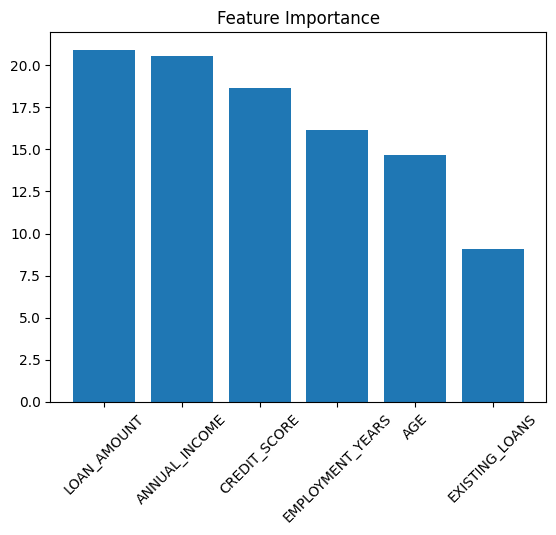

In [14]:
plt.figure()

plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()